# Figure 6 - Brief analysis of Transcription Factor binding Sites

## Goals:
1. Characterize cell cycle nature of cycling transcription factors, prevelence of PTR
2. Characterize which of these are associated with genes and whether those genes are cell cycle (cross-reference with transcription-story)


In [3]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


There are 118 MacIsaac TFs
There are 49 cell cycle transcription factors (CCTFs) profiled by Kelliher, 2018
There are 340 transcription factors profiled using ChIP-exo by Rossi, 2021
There are 17 CCTFS in the Rossi dataset.
There are 22 CCTFS in the MacIsaac dataset.


In [17]:
from src.TranscriptionFactorProcessor import TranscriptionFactorProcessor

# Initialize and run comprehensive analysis
analyzer = TranscriptionFactorProcessor(output_dir='output/draft4_run/')
full_results = analyzer.build_comprehensive_dataframe(include_ptr=True)

# Access different aspects
gene_associations = full_results['associated_genes']  # "CLB5,THI22" format
ptr_values = full_results['ptr'] 
association_stats = analyzer.get_association_summary()


Building comprehensive dataframe with gene associations...
Loading TF binding datasets...
There are 118 MacIsaac TFs
There are 49 cell cycle transcription factors (CCTFs) profiled by Kelliher, 2018
There are 340 transcription factors profiled using ChIP-exo by Rossi, 2021
There are 17 CCTFS in the Rossi dataset.
There are 22 CCTFS in the MacIsaac dataset.
Found 987 high-confidence binding sites for 17 cell cycle TFs
Preparing binding site coordinates...
Prepared 987 binding sites with ±40bp windows
Loading and processing chromatin data...
Processing site 1/987
Processing site 51/987
Processing site 101/987
Processing site 151/987
Processing site 201/987
Processing site 251/987
Processing site 301/987
Processing site 351/987
Processing site 401/987
Processing site 451/987
Processing site 501/987
Processing site 551/987
Processing site 601/987
Processing site 651/987
Processing site 701/987
Processing site 751/987
Processing site 801/987
Processing site 851/987
Processing site 901/987
Er

/Users/trung/Research/deconvolution-python/src/TranscriptionFactorProcessor.py:196: RuntimeWarning: Mean of empty slice.
  mean_binding_data = binding_site_data.mean((1, 2))
/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/numpy/core/_methods.py:184: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Processing site 951/987
Successfully processed 987 binding sites
Loading gene promoter data...
Loaded 5774 gene promoters
Finding TF-gene associations...
Found gene associations for 305/987 TF binding sites
Calculating peak-to-trough ratios...
Added PTR values (mean: 1.170)
Integrating gene association data...
Added gene associations: 305 sites with gene overlaps
Comprehensive dataframe complete with 987 sites


In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_tf_boxplots(df, column='ptr', figsize=(8, 4), 
                     title="Transcription factor PTRs", 
                     color=plt.cm.Oranges(0.35), show_outliers=True, 
                     rotate_labels=None):
    """
    Plot box plots for specified column values grouped by transcription factor (tf).
    """
    
    # Validate input
    if column not in df.columns:
        raise ValueError(f"Column '{column}' not found in DataFrame")
    
    if not isinstance(df.index, pd.MultiIndex) or len(df.index.names) < 2:
        raise ValueError("DataFrame must have multi-index with at least 2 levels")
    
    # Group by 'tf' level and extract specified column values
    tf_groups = df.groupby(level='tf')[column]
    
    # Prepare data for box plots
    data_list = []
    tf_names = []
    
    for tf_name, group in tf_groups:
        # Remove any NaN values
        clean_data = group.dropna().values
        if len(clean_data) > 0:  # Only include if there's data
            data_list.append(clean_data)
            tf_names.append(tf_name)
    
    if not data_list:
        raise ValueError("No valid data found for plotting")
    
    # Create the box plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create box plots
    box_plot = ax.boxplot(data_list, labels=tf_names, patch_artist=True, 
                         showfliers=show_outliers)
    
    # Color the boxes
    for patch in box_plot['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Customize the plot
    ax.set_xlabel('Transcription Factor', fontsize=12)
    ax.set_ylabel(f'{column.upper()} Value', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='demi')
    
    # Handle label rotation
    if rotate_labels is None:
        # Auto-rotate if more than 8 factors
        if len(tf_names) > 8:
            rotate_labels = 45
        else:
            rotate_labels = 0
    
    if rotate_labels > 0:
        plt.xticks(rotation=rotate_labels, ha='right')
    
    # Add some statistics as text
    n_factors = len(tf_names)
    total_sites = sum(len(data) for data in data_list)
        
    return fig, ax


(<Figure size 800x400 with 1 Axes>,
 <Axes: title={'center': 'Transcription factor PTRs'}, xlabel='Transcription Factor', ylabel='PTR Value'>)

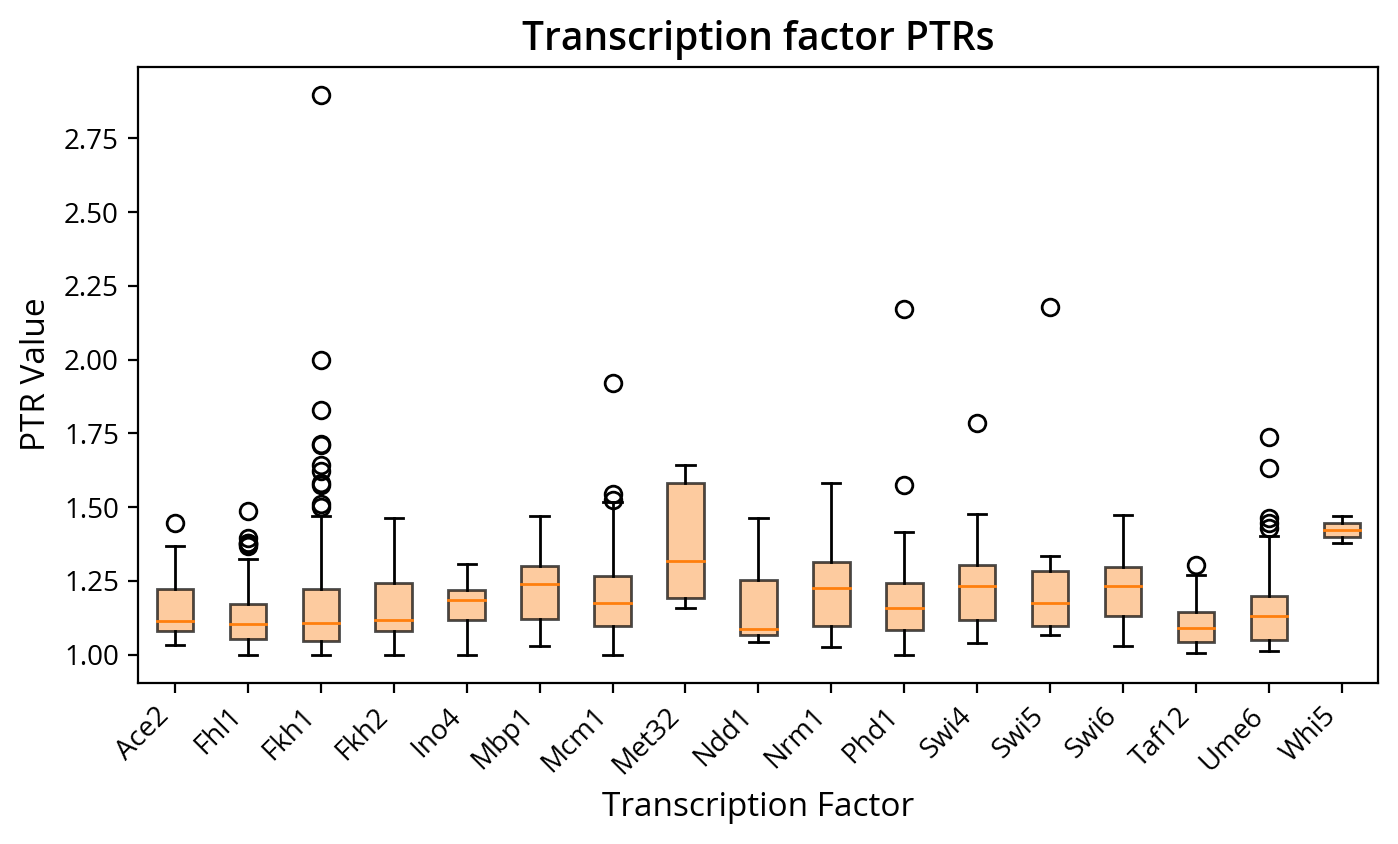

In [15]:
plot_tf_boxplots(full_results)